## Backtesting a strategy using three moving averages on any indices Nifty50

In [74]:
#importing all the required library

import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

import warnings
warnings.filterwarnings("ignore")

In [75]:
#Loading data for Quant analyses

ticker = "^NSEI"
start_date = '2024-01-01'
end_date = '2025-12-31'
data = yf.download(ticker, start_date, end_date, multi_level_index = False)

[*********************100%***********************]  1 of 1 completed


In [76]:
#Inspecting data
print("\nFirst few rows:")
print(data.head())
print("\nCount of row:")
print(data['Close'].count())


First few rows:
                   Close          High           Low          Open  Volume
Date                                                                      
2024-01-01  21741.900391  21834.349609  21680.849609  21727.750000  154000
2024-01-02  21665.800781  21755.599609  21555.650391  21751.349609  263700
2024-01-03  21517.349609  21677.000000  21500.349609  21661.099609  311900
2024-01-04  21658.599609  21685.650391  21564.550781  21605.800781  339200
2024-01-05  21710.800781  21749.599609  21629.199219  21705.750000  309300

Count of row:
494


In [77]:
def generate_returns(stock):
    data['p_returns'] = data['Close'].pct_change()
    return data

In [78]:

def triple_ma_strategy(df ,avg1 ,avg2 ,avg3 ,print_chart):
    data = df.copy()
    
#Compute three moving averages of 20, 40, and 80.
    data['moving_avg_20'] = data['Close'].rolling(window=avg1).mean()
    data['moving_avg_40'] = data['Close'].rolling(window=avg2).mean()
    data['moving_avg_80'] = data['Close'].rolling(window=avg3).mean()
    
    #GCrating signal
    data['signal']= np.nan
    n = data.shape[0]
    
    for i in range(1, n): 
    #1. Very first row handling:
    #Forces the signal on the first row to 0.
        if i == 1:
            data['signal'].iloc[i-1] = 0.0
        
        #check if any mov avg has null value
        if data[['moving_avg_20','moving_avg_40','moving_avg_80']].iloc[i].isnull().values.any():
            data['signal'].iloc[i] = 0.0
            continue
            
        ## Set the conditions per each moving average
        cond_sma = data['Close'].iloc[i] >= data['moving_avg_20'].iloc[i]
        cond_mma = data['Close'].iloc[i] >= data['moving_avg_40'].iloc[i]
        cond_lma = data['Close'].iloc[i] >= data['moving_avg_80'].iloc[i]
        
        #if we have current position
        if pd.isna(data['signal'].iloc[i-1]) or data['signal'].iloc[i-1] == 0.0:
            if cond_sma & cond_mma & cond_lma:          # → Go Long Price is above all 3 moving averages
                data['signal'].iloc[i] = 1.0
            elif (cond_sma==False) & (cond_mma==False) & (cond_lma==False):
                data['signal'].iloc[i] = -1.0           # → Go Short Price is below all 3 moving averages
            else:
                data['signal'].iloc[i] = 0.0
        
            #check if we are long today
        elif data['signal'].iloc[i-1] == 1.0:
            if (cond_sma == False) | (cond_mma==False) | (cond_lma==False):    #If price falls below ANY one MA
                data['signal'].iloc[i] = 0.0
            else:
                data['signal'].iloc[i] = 1.0
        
        elif data['signal'].iloc[i-1] == -1.0:
            if cond_sma | cond_mma | cond_lma:        #If price goes above ANY one MA
                data['signal'].iloc[i] = 0.0
            else:
                data['signal'].iloc[i] = -1.0
    
    if print_chart == True:
        data[['signal', 'moving_avg_20', 'moving_avg_40', 'moving_avg_80', 'Close']].iloc[50:130].plot(figsize=(10, 6), secondary_y='signal')

    # Compute the strategy returns
    data['strategy_returns'] = data['p_returns'] * data['signal'].shift(1)
    
    return data

In [84]:
def calculate_return(data):
    bnh = (data['p_returns']+1).cumprod()[-1]
    s_returns = (data['strategy_returns']+1).cumprod()[-1]

    return bnh, s_returns

Buy and hold returns: 1.19
Strategy returns: 1.04


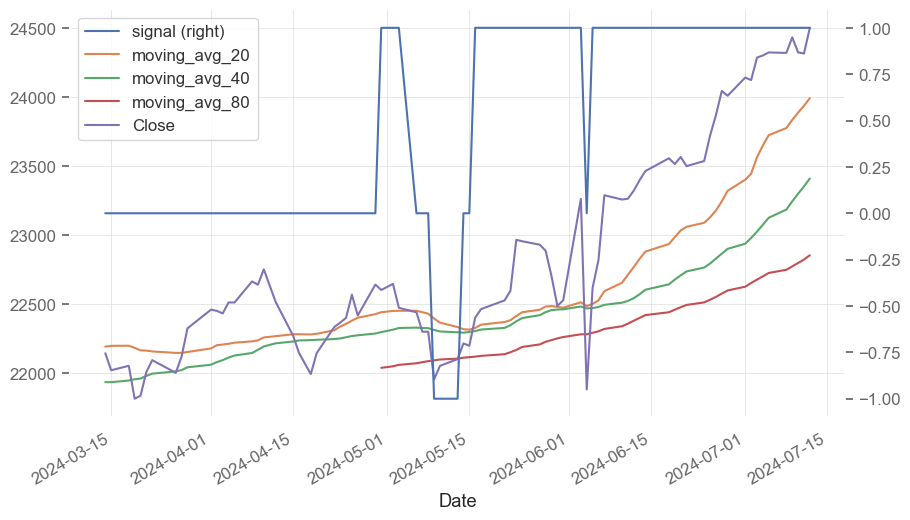

In [85]:
data = generate_returns(data)
data = triple_ma_strategy(data, 20, 40, 80, True)

bnh, s_returns = calculate_return(data)

print('Buy and hold returns:', np.round(bnh, 2))
print('Strategy returns:', np.round(s_returns, 2))

In [86]:
# Get the summary statistics for the strategy using pyfolio
!pip install quantstats
import quantstats as qs  


Parameter       Value
--------------  -------
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Strategy
-------------------  ----------
Start Period         2024-01-02
End Period           2025-12-30
Risk-Free Rate       0.0%
Time in Market       64.0%

Cumulative Return    4.16%
CAGR﹪               2.1%

Sharpe               0.25
Prob. Sharpe Ratio   63.46%
Sortino              0.35
Sortino/√2           0.24
Omega                1.06

Max Drawdown         -7.61%
Max DD Date          2025-04-15
Max DD Period Start  2025-03-05
Max DD Period End    2025-12-30
Longest DD Days      301

Gain/Pain Ratio      0.06
Gain/Pain (1M)       0.4

Payoff Ratio         0.89
Profit Factor        1.06
Common Sense Ratio   1.21
CPC Index            0.51
Tail Ratio           1.14
Outlier Win Ratio    6.84
Outlier Loss Ratio   3.23

MTD                  -1.87%
3M                   0.72%
6M                   -3.44%
YTD                  -1.41%
1Y      

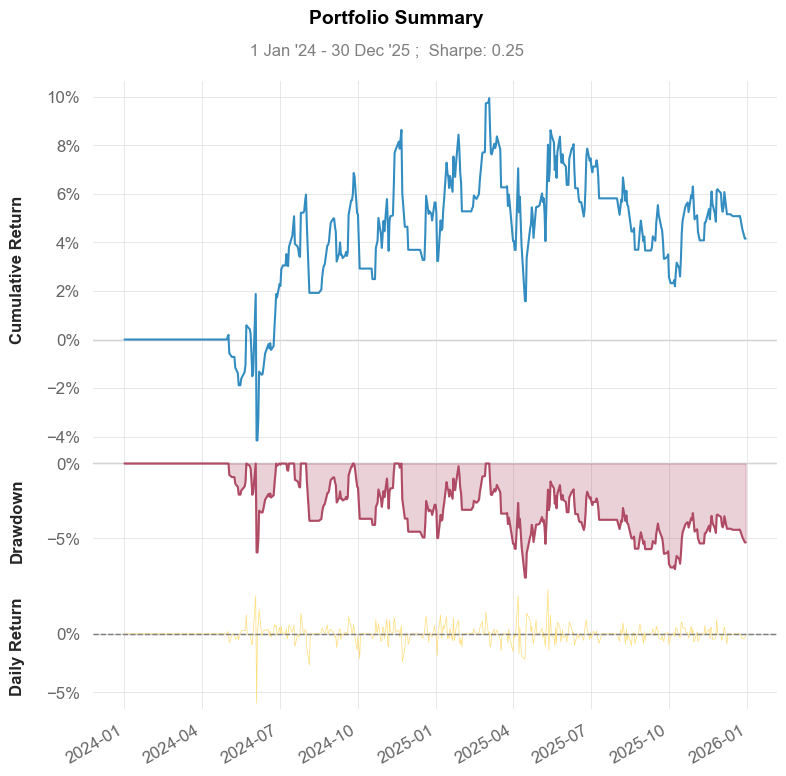

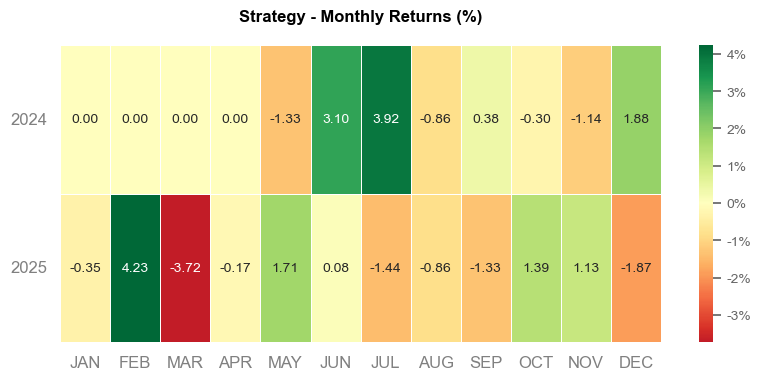

In [87]:

qs.reports.basic(data['strategy_returns'])

Start date,2024-01-01
End date,2025-12-30
Total months,23
,Backtest
Annual return,2.099%
Cumulative returns,4.156%
Annual volatility,10.721%
Sharpe ratio,0.25
Calmar ratio,0.28
Stability,0.49
Max drawdown,-7.605%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,7.61,2025-03-04,2025-04-15,NaT,NaN
1,5.93,2024-06-03,2024-06-04,2024-07-01,21
2,4.97,2024-11-21,2025-01-02,2025-02-28,72
3,4.09,2024-09-26,2024-10-18,2024-11-13,35
4,3.82,2024-08-01,2024-08-05,2024-09-25,40


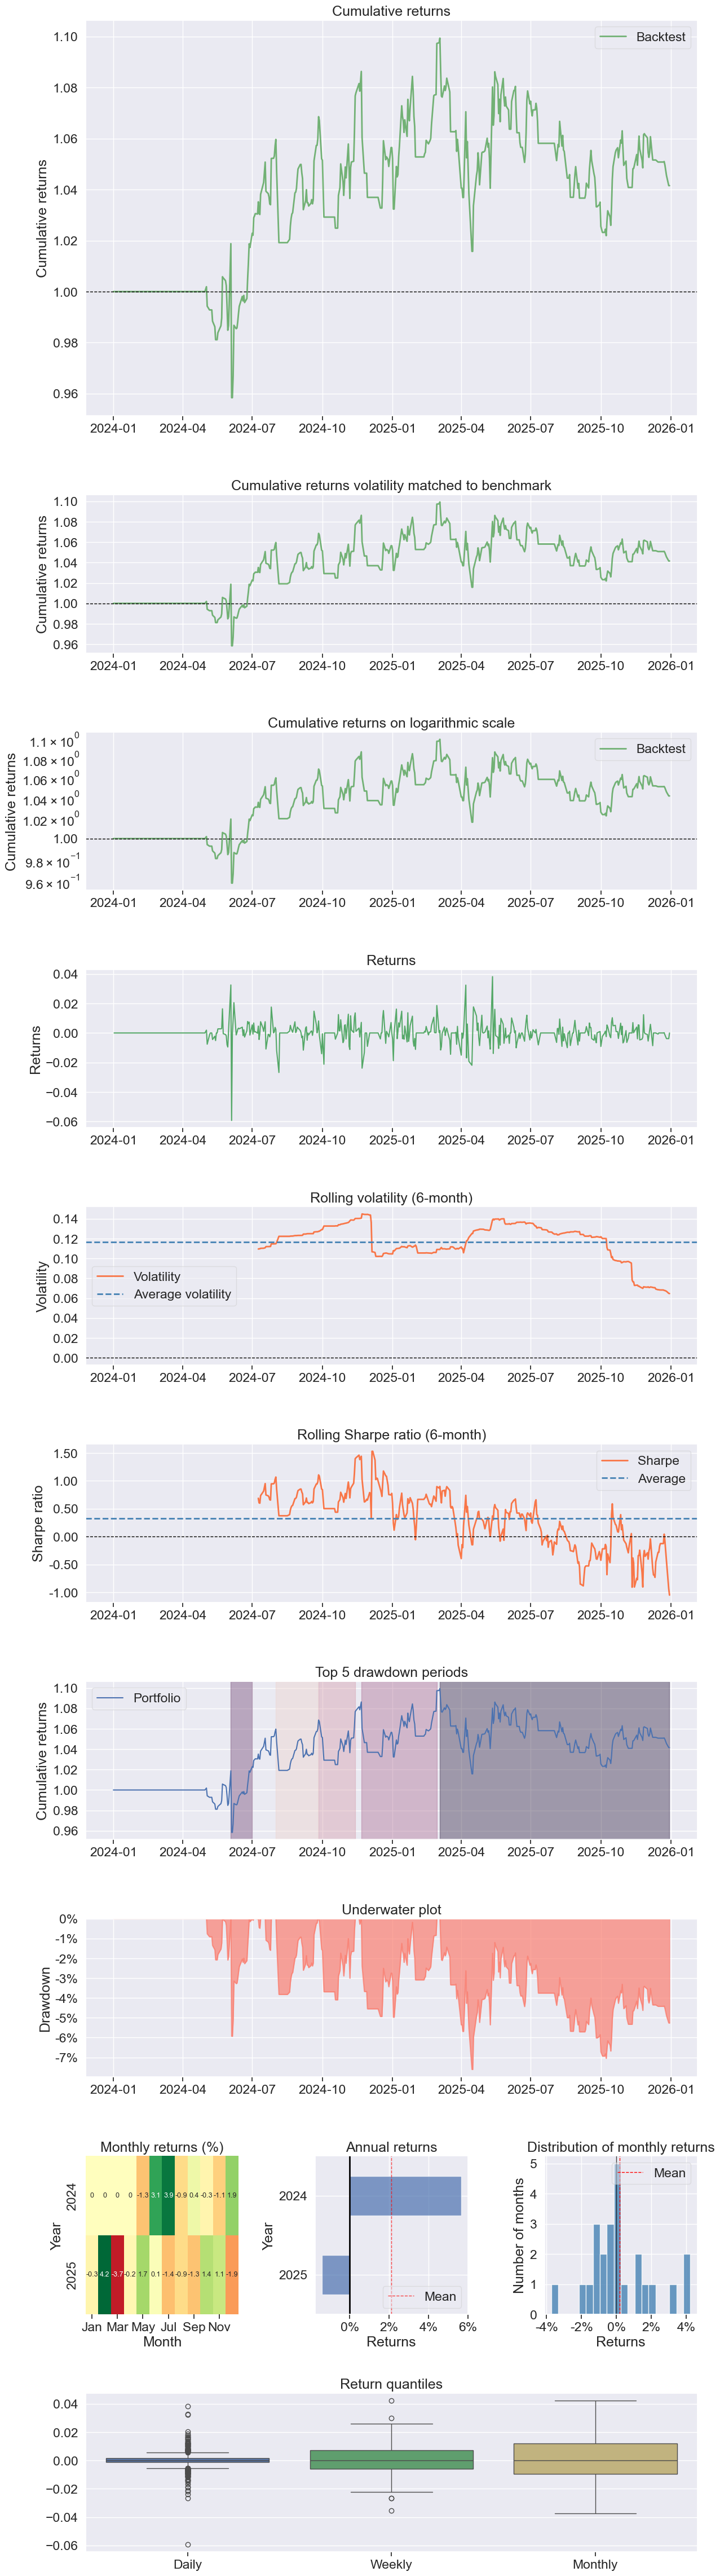

In [88]:
# Get the summary statistics for the strategy using pyfolio
!pip install pyfolio-reloaded
import pyfolio as pf

pf.create_full_tear_sheet(data['strategy_returns'])

In [89]:
trade_sheet = pd.DataFrame({
    'Date': data.index,
    'Close': data['Close'],
    'Daily returns': data['p_returns'],
    'strategy_returns': data['strategy_returns'],
    'signal': data['signal'],
    'moving_avg_20': data['moving_avg_20'],
    'moving_avg_40': data['moving_avg_40'],
    'moving_avg_80': data['moving_avg_80'],
    'bnh' : bnh
})

print(trade_sheet)

                 Date         Close  Daily returns  strategy_returns  signal  \
Date                                                                           
2024-01-01 2024-01-01  21741.900391            NaN               NaN     0.0   
2024-01-02 2024-01-02  21665.800781      -0.003500         -0.000000     0.0   
2024-01-03 2024-01-03  21517.349609      -0.006852         -0.000000     0.0   
2024-01-04 2024-01-04  21658.599609       0.006564          0.000000     0.0   
2024-01-05 2024-01-05  21710.800781       0.002410          0.000000     0.0   
...               ...           ...            ...               ...     ...   
2025-12-23 2025-12-23  26177.150391       0.000181          0.000181     1.0   
2025-12-24 2025-12-24  26142.099609      -0.001339         -0.001339     1.0   
2025-12-26 2025-12-26  26042.300781      -0.003818         -0.003818     1.0   
2025-12-29 2025-12-29  25942.099609      -0.003848         -0.003848     0.0   
2025-12-30 2025-12-30  25938.849609     

In [92]:
df = trade_sheet.to_csv('C:/Users/gaura/Main_Project_EPAT/trade_sheet_3movavg1.csv')

In [67]:
import os
print(os.getcwd())

C:\Users\gaura\Main_Project_EPAT


In [95]:
data2 = yf.download('^NSEI', '2015-1-1', '2020-12-31')
ma_dict = {}

# Optimize the strategy
for sma in range(30, 40, 5):
    for mma in range(60, 75, 5):
        for lma in range(100, 115, 5):
            key = 'sma'+str(sma)+'_mma'+str(mma)+'_lma'+str(lma)
            print(f'\nChecking for SMA: {sma}, MMA: {mma}, LMA: {lma}')
            df = data.copy()
            df = data = generate_returns(df)
            df = triple_ma_strategy(df, sma, mma, lma, False)
            bnh, s_returns = calculate_return(df)
            print('Buy and hold returns:', np.round(bnh, 2))
            print('Strategy returns:', np.round(s_returns, 2))
            ma_dict[key] = s_returns
else:
    print('Computation Completed.')

# Print the sma, mma, lma values that yield the max strategy returns
max_ret = max(ma_dict.values())
opt_values = [key for key, value in ma_dict.items() if value == max_ret]
print(f"The max strategy returns are {max_ret} for the values {opt_values}.")

[*********************100%***********************]  1 of 1 completed



Checking for SMA: 30, MMA: 60, LMA: 100
Buy and hold returns: 1.19
Strategy returns: 1.02

Checking for SMA: 30, MMA: 60, LMA: 105
Buy and hold returns: 1.19
Strategy returns: 1.06

Checking for SMA: 30, MMA: 60, LMA: 110
Buy and hold returns: 1.19
Strategy returns: 1.01

Checking for SMA: 30, MMA: 65, LMA: 100
Buy and hold returns: 1.19
Strategy returns: 1.02

Checking for SMA: 30, MMA: 65, LMA: 105
Buy and hold returns: 1.19
Strategy returns: 1.06

Checking for SMA: 30, MMA: 65, LMA: 110
Buy and hold returns: 1.19
Strategy returns: 1.01

Checking for SMA: 30, MMA: 70, LMA: 100
Buy and hold returns: 1.19
Strategy returns: 1.01

Checking for SMA: 30, MMA: 70, LMA: 105
Buy and hold returns: 1.19
Strategy returns: 1.05

Checking for SMA: 30, MMA: 70, LMA: 110
Buy and hold returns: 1.19
Strategy returns: 1.0

Checking for SMA: 35, MMA: 60, LMA: 100
Buy and hold returns: 1.19
Strategy returns: 1.06

Checking for SMA: 35, MMA: 60, LMA: 105
Buy and hold returns: 1.19
Strategy returns: 1.11
